<h1 style="color: rgb(64, 0, 255); text-align: center;">Messier 12 Globular Cluster</h1>

In [20]:
#installing the required libraries
# !pip install astropy photutils matplotlib numpy

In [21]:
#importing the required libraries
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats

# Reading data from the given Vcomb.fits file

In [22]:
# Loading the FITS file
file_path = '/home/Interstellar/Desktop/M12_Analysis/data/Vcomb.fits'
hdul = fits.open(file_path)
header = hdul[0].header
data = hdul[0].data
hdul.close()

# Printing basic information about the data
print("Data shape:", data.shape)
print(hdul.info())
header

Data shape: (2048, 2048)
Filename: /home/Interstellar/Desktop/M12_Analysis/data/Vcomb.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     323   (2048, 2048)   float32   
None


SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                 2048 / Axis length                                    
NAXIS2  =                 2048 / Axis length                                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 1999' / FITS file originator        
DATE    = '2001-08-21T09:32:56' / Date FITS file was generated                  
IRAF-TLM= '10:32:40 (21/08/2001)' / Time of last modification                   
OBJECT  = '        '           / Name of the object observed                    
EXTEND  =                    T / FITS extension may be present                  
                                                                                
CRPIX1  =               1005.1 / Reference pixel                                
CRVAL1  =             251.76

In [23]:
data

array([[ 386.98688  ,  216.82008  ,  141.31346  , ...,    7.3254576,
          10.790693 ,    7.8435125],
       [ 818.1782   ,  395.3559   ,  221.47505  , ...,   12.947803 ,
          10.293222 ,    8.837242 ],
       [1699.8933   ,  731.9462   ,  356.73483  , ...,    9.888079 ,
           9.512111 ,   10.03224  ],
       ...,
       [  31.248117 ,   33.255642 ,   39.49389  , ...,    8.543327 ,
          10.336281 ,    9.096804 ],
       [  22.404367 ,   33.17108  ,   40.054565 , ...,    8.378468 ,
           8.731696 ,    6.6440377],
       [  25.225891 ,   34.42369  ,   37.03104  , ...,    6.400644 ,
           7.017972 ,    6.509126 ]], shape=(2048, 2048), dtype='>f4')

In [24]:
# the brightest pixel value in the data
max_pixel_value = np.max(data)
print("Brightest Pixel Value:", max_pixel_value)

# the darkest pixel value in the data
min_pixel_value = np.min(data)
print("Darkest Pixel Value:", min_pixel_value)

# the mean pixel value in the data
mean_pixel_value = np.mean(data)
print("Mean Pixel Value:", mean_pixel_value)

Brightest Pixel Value: 66217.84
Darkest Pixel Value: -10.660466
Mean Pixel Value: 20.450367


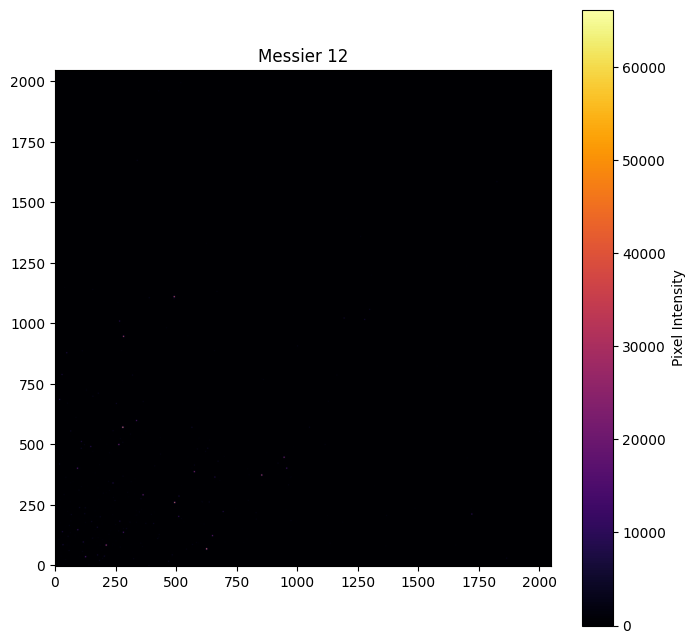

In [25]:
# Visualizing the data
plt.figure(figsize=(8,8))
plt.imshow(data, cmap='inferno', origin='lower')
plt.colorbar(label="Pixel Intensity")
plt.title("Messier 12")
plt.show()

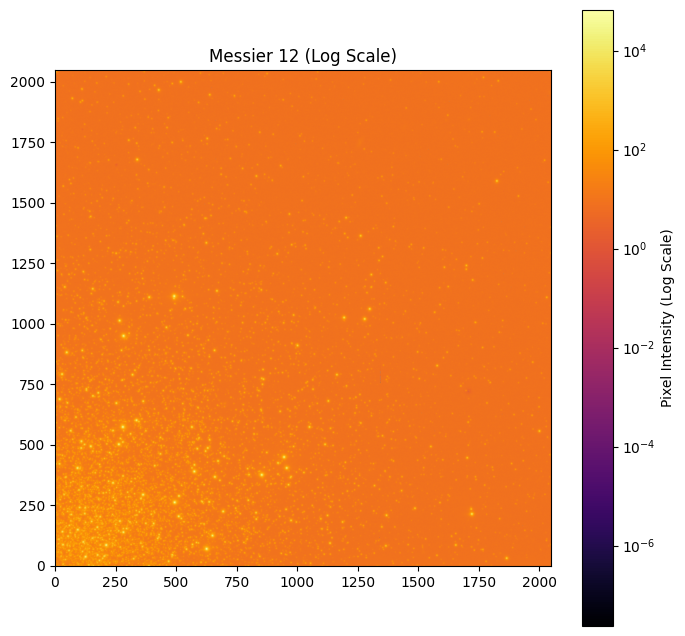

In [26]:
# using Logarithmic scaling to enhance the visibility
from matplotlib.colors import LogNorm
plt.figure(figsize=(8,8))
plt.imshow(data, cmap='inferno', origin='lower', norm=LogNorm())
plt.colorbar(label="Pixel Intensity (Log Scale)")
plt.title("Messier 12 (Log Scale)")
plt.show()

# Estimating the background statistics of the data using Sigma Clipping

In [27]:
# Estimating background statistics using sigma clipping
bg_mean, bg_median, bg_std = sigma_clipped_stats(data, sigma=3.0)
print("Background Mean:", bg_mean, "ADU")
print("Background Median:", bg_median, "ADU")
print("Background Standard Deviation:", bg_std, "ADU")

Background Mean: 9.284391 ADU
Background Median: 8.9999895 ADU
Background Standard Deviation: 2.2605705 ADU


# Detecting stars using the DAOStarFinder Algorithm

In [28]:
# !pip install photutils[all]

In [29]:
from photutils.detection import DAOStarFinder

daofind = DAOStarFinder(fwhm=3.0, threshold=5.0*bg_std)
stars = daofind(data - bg_median)
for col in stars.colnames:
    if col not in ('id', 'npix'):
        stars[col].info.format = '%.2f'
stars.pprint(max_width=76)

 id  x_centroid y_centroid sharpness ...   peak    flux    mag   daofind_mag
---- ---------- ---------- --------- ... ------- -------- ------ -----------
   1     245.59       0.55      0.82 ...  318.59  2248.85  -8.38       -3.05
   2     332.22       0.42      0.82 ...  230.54  1413.07  -7.88       -2.78
   3     386.81       0.40      0.81 ... 7973.94 47713.70 -11.70       -6.65
   4     502.57       0.66      0.79 ...   90.15   724.10  -7.15       -1.65
   5     546.26       0.54      0.75 ...  158.28  1052.43  -7.56       -2.43
   6     727.27       0.48      0.80 ...   43.06   268.12  -6.07       -0.98
   7     909.82       0.63      0.76 ...   25.04   181.08  -5.64       -0.36
   8    1120.95       0.69      0.69 ...   54.12   396.18  -6.49       -1.30
   9      13.82       1.09      0.33 ...  104.15  1491.60  -7.93       -1.91
  10      40.06       0.62      0.31 ...  397.69  4702.12  -9.18       -3.70
 ...        ...        ...       ... ...     ...      ...    ...         ...

In [30]:
# converting the detected stars to a pandas DataFrame and saving it as a CSV file
stars_df = stars.to_pandas()
stars_df.to_csv('/home/Interstellar/Desktop/M12_Analysis/data/detected_stars.csv', index=False)

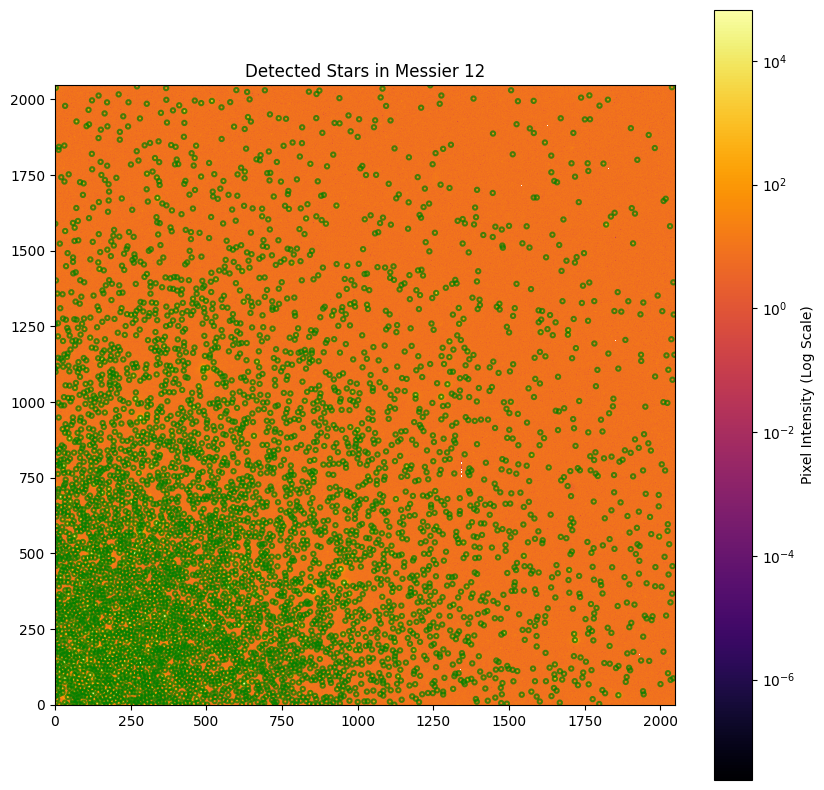

In [31]:
from photutils.aperture import CircularAperture

positions = np.transpose((stars['x_centroid'], stars['y_centroid']))
apertures = CircularAperture(positions, r=7)

# Visualize the detected stars
plt.figure(figsize=(10,10))
plt.imshow(data, cmap='inferno', origin='lower', norm=LogNorm(), interpolation='nearest')
apertures.plot(color='green', lw=1.5, alpha=0.7)
plt.colorbar(label="Pixel Intensity (Log Scale)")
plt.title("Detected Stars in Messier 12")
plt.show()

In [32]:
# Finding the brightest star among the detected stars
brightest_star = stars[np.argmax(stars['peak'])]
print("Brightest Star:")
print("ID:", brightest_star['id'])
print("X Centroid:", brightest_star['x_centroid'],"px")
print("Y Centroid:", brightest_star['y_centroid'],"px")
print("Peak Intensity:", brightest_star['peak'],"ADU")
print("flux:", brightest_star['flux'],"ADU") 
print("magnitude:", brightest_star['mag'])

Brightest Star:
ID: 2669
X Centroid: 279.25034233820736 px
Y Centroid: 572.5437982407675 px
Peak Intensity: 66207.25 ADU
flux: 940086.25 ADU
magnitude: -14.9329195


In [33]:
# Finding the faintest star among the detected stars
faintest_star = stars[np.argmin(stars['peak'])]
print("Faintest Star:")
print("ID:", faintest_star['id'])
print("X Centroid:", faintest_star['x_centroid'],"px")
print("Y Centroid:", faintest_star['y_centroid'],"px")
print("Peak Intensity:", faintest_star['peak'],"ADU")
print("flux:", faintest_star['flux'],"ADU")
print("magnitude:", faintest_star['mag'])

Faintest Star:
ID: 4664
X Centroid: 1067.682091428758 px
Y Centroid: 1561.2324057606895 px
Peak Intensity: 11.728911 ADU
flux: 130.4512 ADU
magnitude: -5.28862


# Plotting a histogram of the flux of the detected stars

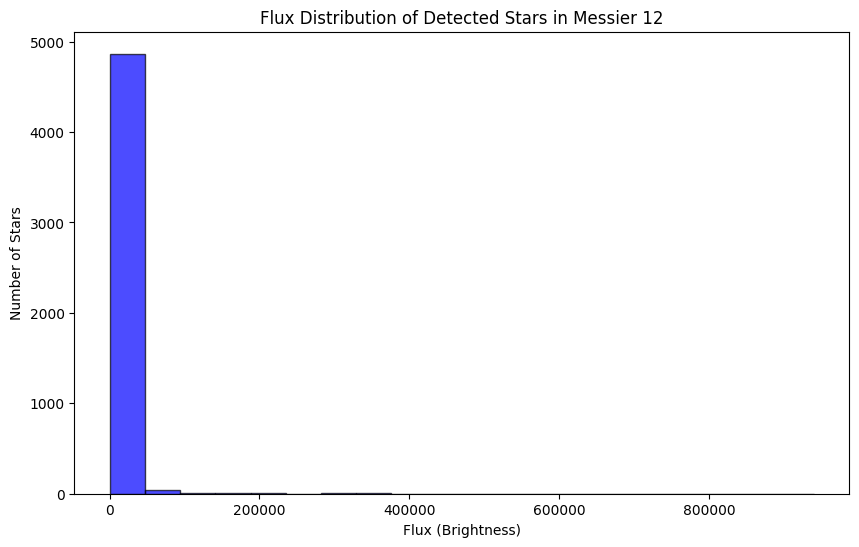

In [34]:
# Extracting the flux values of the detected sources and plotting a histogram to visualize the distribution of fluxes among the detected stars
fluxes = stars['flux']

# Histogram
plt.figure(figsize=(10,6))
plt.hist(fluxes,bins=20,color='blue',edgecolor='black',alpha=0.7)

# Labels and title
plt.xlabel('Flux (Brightness)')
plt.ylabel('Number of Stars')
plt.title('Flux Distribution of Detected Stars in Messier 12')
plt.show()

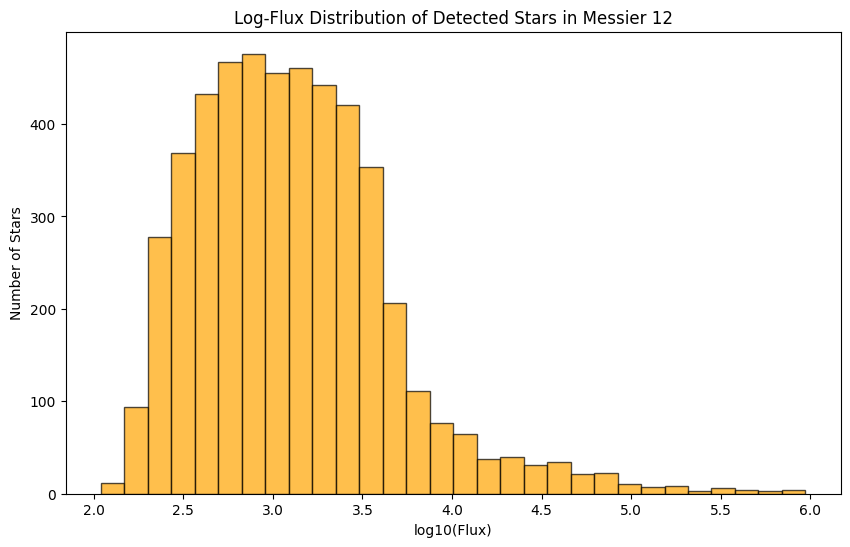

In [35]:
# Convert flux values to logarithmic scale
log_fluxes = np.log10(fluxes)

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(log_fluxes,bins=30,color='orange',edgecolor='black',alpha=0.7)
plt.xlabel('log10(Flux)')
plt.ylabel('Number of Stars')
plt.title('Log-Flux Distribution of Detected Stars in Messier 12')
plt.show()